<Axes: >

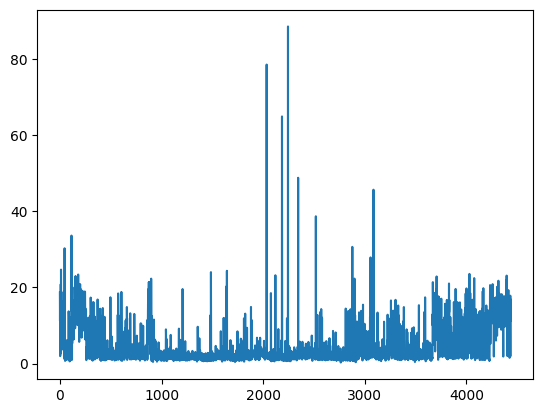

In [21]:
import pandas

data = pandas.read_csv('exoplanet_data.csv')
data = data[data['pl_controv_flag'] == 0]
data['radius'] = data['pl_rade']

data = data[data['radius'].notna()]
# data = data.drop_duplicates(subset = 'pl_name')
# data = data.drop_duplicates(subset = 'pl_rade')

data = data.sort_values(by = ['pl_name', 'disc_year'], ascending = [True, False])
data = data.drop_duplicates(subset = 'pl_name').reset_index(drop = True)

x = data['radius']
x = x[x < 100]
x.plot()

In [25]:
from sklearn.cluster import KMeans
import numpy

kmeans = KMeans(n_clusters = 2)
labels = kmeans.fit_predict(x.to_numpy().reshape(-1, 1))
jovian = x[labels == numpy.argmax(kmeans.cluster_centers_.flatten())]
terran = x[labels == numpy.argmin(kmeans.cluster_centers_.flatten())]

print(numpy.mean(jovian) + numpy.std(jovian) * 3)

30.21814052114792
